**© Copyright AIDENTIFY. All rights reserved.**

# Part 1 | Session 3: 트랜스포머 아키텍처 - Attention, BERT, GPT 구조 비교

이 노트북에서는 트랜스포머 아키텍처의 핵심 개념을 학습하고, BERT와 GPT의 구조적 차이를 이해합니다.

### 학습 목표
- Transformer의 Encoder-Decoder 구조 이해
- Self-Attention 메커니즘의 수학적 원리 파악
- BERT와 GPT의 구조적 차이점 비교
- HuggingFace를 활용한 실습

In [1]:
# 💡 setup.sh 실행했으면 이 셀은 건너뛰세요 (참고용 — 본 노트북이 필요로 하는 패키지)
# 필요한 패키지 설치
# !pip install -q torch transformers matplotlib numpy


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.10.0+cu128
CUDA available: True


---
## 1️⃣ Transformer 아키텍처 개요

### Encoder-Decoder 구조

2017년 Google의 논문 **"Attention Is All You Need"** 에서 제안된 Transformer는 기존 RNN/LSTM 기반 모델의 한계를 극복한 아키텍처입니다.

```
┌─────────────────────────────────────────────┐
│              Transformer 구조                │
├──────────────────┬──────────────────────────┤
│    Encoder       │       Decoder            │
│  ┌────────────┐  │  ┌────────────────────┐  │
│  │ Multi-Head  │  │  │ Masked Multi-Head  │  │
│  │ Attention   │  │  │ Attention          │  │
│  ├────────────┤  │  ├────────────────────┤  │
│  │ Add & Norm │  │  │ Add & Norm         │  │
│  ├────────────┤  │  ├────────────────────┤  │
│  │ Feed       │  │  │ Cross-Attention    │  │
│  │ Forward    │  │  │ (Encoder output)   │  │
│  ├────────────┤  │  ├────────────────────┤  │
│  │ Add & Norm │  │  │ Feed Forward       │  │
│  └────────────┘  │  │ + Add & Norm       │  │
│     × N layers   │  └────────────────────┘  │
│                  │     × N layers           │
└──────────────────┴──────────────────────────┘
```

**핵심 특징:**
- **병렬 처리**: RNN과 달리 시퀀스를 동시에 처리 가능
- **Self-Attention**: 입력 시퀀스 내 모든 위치 간 관계를 직접 학습
- **Positional Encoding**: 위치 정보를 별도로 주입

### Self-Attention 메커니즘 (수학적 설명)

Self-Attention은 **Query(Q), Key(K), Value(V)** 세 가지 벡터를 사용합니다.

입력 행렬 $X \in \mathbb{R}^{n \times d}$ 가 주어지면:

$$Q = XW^Q, \quad K = XW^K, \quad V = XW^V$$

여기서 $W^Q, W^K \in \mathbb{R}^{d \times d_k}$, $W^V \in \mathbb{R}^{d \times d_v}$ 는 학습 가능한 가중치 행렬입니다.

**Scaled Dot-Product Attention:**

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

**왜 $\sqrt{d_k}$로 나누는가?**
- $d_k$가 커질수록 내적 값의 분산이 커져 softmax가 극단적 값(0 또는 1에 가까운 값)을 출력
- 이를 방지하기 위해 스케일링하여 기울기(gradient)가 안정적으로 흐르게 함

### Multi-Head Attention

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h)W^O$$

$$\text{head}_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V)$$

- 여러 개의 attention head가 **서로 다른 표현 부분공간(subspace)** 에서 정보를 학습
- 예: head 1은 문법적 관계, head 2는 의미적 관계를 학습할 수 있음

### Positional Encoding (Sinusoidal)

Transformer는 순서 정보가 없으므로 위치 인코딩을 추가합니다:

$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)$$

$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)$$

- $pos$: 시퀀스에서의 위치
- $i$: 차원 인덱스
- 서로 다른 주파수의 sin, cos 함수를 사용하여 고유한 위치 벡터를 생성
- **장점**: 학습 없이 생성 가능, 학습 데이터보다 긴 시퀀스에도 일반화 가능

---
## 2️⃣ Self-Attention 직접 구현

PyTorch로 Scaled Dot-Product Attention을 직접 구현해봅시다.

In [3]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Scaled Dot-Product Attention 구현
    
    Args:
        Q: Query 행렬 (batch, seq_len, d_k)
        K: Key 행렬   (batch, seq_len, d_k)
        V: Value 행렬 (batch, seq_len, d_v)
        mask: 마스크 (optional)
    
    Returns:
        output: Attention 결과
        attention_weights: Attention 가중치
    """
    d_k = Q.size(-1)
    
    # Step 1: Q와 K의 내적 계산
    scores = torch.matmul(Q, K.transpose(-2, -1))  # (batch, seq_len, seq_len)
    print(f"내적 결과 (scores) shape: {scores.shape}")
    
    # Step 2: sqrt(d_k)로 스케일링
    scores = scores / math.sqrt(d_k)
    print(f"스케일링 후 scores:\n{scores[0]}")
    
    # Step 3: 마스크 적용 (optional)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float('-inf'))
        print(f"마스크 적용 후 scores:\n{scores[0]}")
    
    # Step 4: Softmax로 가중치 계산
    attention_weights = F.softmax(scores, dim=-1)
    print(f"Attention 가중치:\n{attention_weights[0]}")
    
    # Step 5: 가중치와 V의 가중합
    output = torch.matmul(attention_weights, V)
    
    return output, attention_weights

In [4]:
# 간단한 예시로 Self-Attention 동작 확인
torch.manual_seed(42)

batch_size = 1
seq_len = 4     # 시퀀스 길이 (예: 4개의 토큰)
d_model = 8     # 모델 차원
d_k = 8         # Key/Query 차원

# 임의의 입력 생성 (실제로는 임베딩 벡터)
X = torch.randn(batch_size, seq_len, d_model)
print(f"입력 X shape: {X.shape}")
print(f"입력 X (토큰 4개, 각 8차원):\n{X[0]}\n")

# 가중치 행렬 (학습 가능한 파라미터)
W_Q = nn.Linear(d_model, d_k, bias=False)
W_K = nn.Linear(d_model, d_k, bias=False)
W_V = nn.Linear(d_model, d_k, bias=False)

# Q, K, V 계산
Q = W_Q(X)
K = W_K(X)
V = W_V(X)
print(f"Q shape: {Q.shape}, K shape: {K.shape}, V shape: {V.shape}\n")

# Attention 계산
output, attn_weights = scaled_dot_product_attention(Q, K, V)
print(f"\n출력 shape: {output.shape}")

입력 X shape: torch.Size([1, 4, 8])
입력 X (토큰 4개, 각 8차원):
tensor([[ 1.9269,  1.4873,  0.9007, -2.1055,  0.6784, -1.2345, -0.0431, -1.6047],
        [-0.7521,  1.6487, -0.3925, -1.4036, -0.7279, -0.5594, -0.7688,  0.7624],
        [ 1.6423, -0.1596, -0.4974,  0.4396, -0.7581,  1.0783,  0.8008,  1.6806],
        [ 1.2791,  1.2964,  0.6105,  1.3347, -0.2316,  0.0418, -0.2516,  0.8599]])

Q shape: torch.Size([1, 4, 8]), K shape: torch.Size([1, 4, 8]), V shape: torch.Size([1, 4, 8])

내적 결과 (scores) shape: torch.Size([1, 4, 4])
스케일링 후 scores:
tensor([[ 0.4428,  0.0150, -0.1450,  0.2133],
        [-0.2337,  0.0387, -0.0665,  0.2461],
        [ 0.1223, -0.2116, -0.2011, -0.8662],
        [-0.1039,  0.3430,  0.6562,  0.0110]], grad_fn=<SelectBackward0>)
Attention 가중치:
tensor([[0.3331, 0.2171, 0.1850, 0.2648],
        [0.1957, 0.2569, 0.2313, 0.3161],
        [0.3556, 0.2547, 0.2574, 0.1323],
        [0.1717, 0.2685, 0.3672, 0.1926]], grad_fn=<SelectBackward0>)

출력 shape: torch.Size([1, 4, 8])


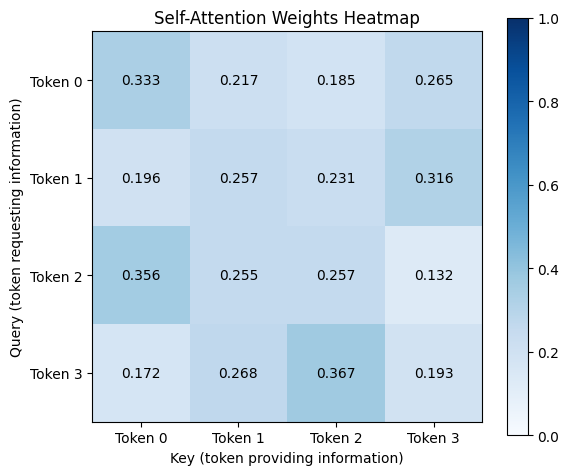

In [5]:
# Attention 가중치 시각화
fig, ax = plt.subplots(figsize=(6, 5))
tokens = ['Token 0', 'Token 1', 'Token 2', 'Token 3']

im = ax.imshow(attn_weights[0].detach().numpy(), cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(seq_len))
ax.set_yticks(range(seq_len))
ax.set_xticklabels(tokens)
ax.set_yticklabels(tokens)
ax.set_xlabel('Key (token providing information)')
ax.set_ylabel('Query (token requesting information)')
ax.set_title('Self-Attention Weights Heatmap')

# 각 셀에 값 표시
for i in range(seq_len):
    for j in range(seq_len):
        ax.text(j, i, f'{attn_weights[0][i][j].item():.3f}',
                ha='center', va='center', fontsize=10)

plt.colorbar(im)
plt.tight_layout()
plt.show()

### Multi-Head Attention 구현

In [6]:
class MultiHeadAttention(nn.Module):
    """Multi-Head Attention 구현"""
    
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model은 num_heads로 나누어떨어져야 합니다"
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads  # 각 head의 차원
        
        # Q, K, V 선형 변환
        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)
        self.W_O = nn.Linear(d_model, d_model)  # 출력 선형 변환
    
    def forward(self, Q, K, V, mask=None):
        batch_size = Q.size(0)
        
        # 1. 선형 변환 후 head별로 분리
        # (batch, seq_len, d_model) -> (batch, num_heads, seq_len, d_k)
        Q = self.W_Q(Q).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_K(K).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_V(V).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        
        # 2. Scaled Dot-Product Attention
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        attn_weights = F.softmax(scores, dim=-1)
        context = torch.matmul(attn_weights, V)
        
        # 3. Head 결합
        # (batch, num_heads, seq_len, d_k) -> (batch, seq_len, d_model)
        context = context.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        
        # 4. 출력 선형 변환
        output = self.W_O(context)
        
        return output, attn_weights

# Multi-Head Attention 테스트
d_model = 64
num_heads = 8
mha = MultiHeadAttention(d_model, num_heads)

X = torch.randn(1, 10, d_model)  # (batch=1, seq_len=10, d_model=64)
output, attn_weights = mha(X, X, X)

print(f"입력 shape: {X.shape}")
print(f"출력 shape: {output.shape}")
print(f"Attention weights shape: {attn_weights.shape}  (batch, heads, seq, seq)")
print(f"각 head의 차원 (d_k): {d_model // num_heads}")

입력 shape: torch.Size([1, 10, 64])
출력 shape: torch.Size([1, 10, 64])
Attention weights shape: torch.Size([1, 8, 10, 10])  (batch, heads, seq, seq)
각 head의 차원 (d_k): 8


---
## 3️⃣ Positional Encoding 시각화

Sinusoidal Positional Encoding을 구현하고 시각화해봅시다.

In [7]:
def get_positional_encoding(max_len, d_model):
    """
    Sinusoidal Positional Encoding 생성
    
    PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
    """
    pe = torch.zeros(max_len, d_model)
    position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)  # (max_len, 1)
    
    # 10000^(2i/d_model) 계산
    div_term = torch.exp(
        torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
    )  # (d_model/2,)
    
    pe[:, 0::2] = torch.sin(position * div_term)  # 짝수 인덱스: sin
    pe[:, 1::2] = torch.cos(position * div_term)  # 홀수 인덱스: cos
    
    return pe

# Positional Encoding 생성
max_len = 100
d_model = 128
pe = get_positional_encoding(max_len, d_model)
print(f"Positional Encoding shape: {pe.shape}  (위치 수, 차원)")

Positional Encoding shape: torch.Size([100, 128])  (위치 수, 차원)


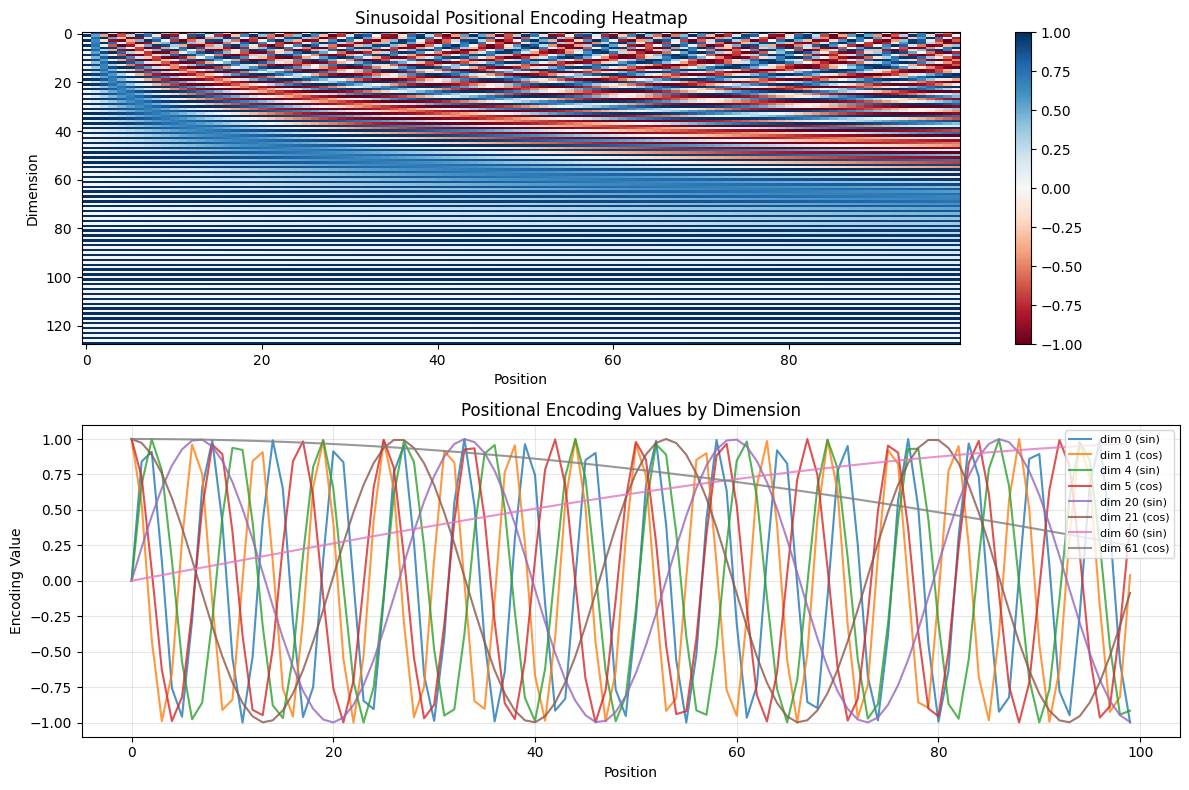


관찰 포인트:
- 낮은 차원(dim 0, 1): 높은 주파수 → 빠르게 변화
- 높은 차원(dim 60, 61): 낮은 주파수 → 천천히 변화
- 각 위치는 고유한 인코딩 벡터를 가짐


In [8]:
# Positional Encoding 시각화
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# 1) 전체 PE 히트맵
ax1 = axes[0]
im = ax1.imshow(pe.numpy(), aspect='auto', cmap='RdBu', interpolation='nearest', origin='lower')
ax1.set_xlabel('Dimension')
ax1.set_ylabel('Position')
ax1.set_title('Sinusoidal Positional Encoding Heatmap')
plt.colorbar(im, ax=ax1)

# 2) 특정 차원의 PE 값 변화
ax2 = axes[1]
dims_to_plot = [0, 1, 4, 5, 20, 21, 60, 61]
for dim in dims_to_plot:
    label = f'dim {dim} ({"sin" if dim % 2 == 0 else "cos"})'
    ax2.plot(pe[:, dim].numpy(), label=label, alpha=0.8)

ax2.set_xlabel('Position')
ax2.set_ylabel('Encoding Value')
ax2.set_title('Positional Encoding Values by Dimension')
ax2.legend(loc='upper right', fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n관찰 포인트:")
print("- 낮은 차원(dim 0, 1): 높은 주파수 → 빠르게 변화")
print("- 높은 차원(dim 60, 61): 낮은 주파수 → 천천히 변화")
print("- 각 위치는 고유한 인코딩 벡터를 가짐")

---
## 4️⃣ BERT 구조

### BERT (Bidirectional Encoder Representations from Transformers)

BERT는 Transformer의 **Encoder만** 사용하는 모델입니다.

```
┌─────────────────────────────────────────┐
│              BERT 구조                   │
│                                         │
│  [CLS] 나는 [MASK] 을 좋아한다 [SEP]     │
│    ↓     ↓     ↓    ↓     ↓      ↓     │
│  ┌─────────────────────────────────┐    │
│  │  Token Embedding               │    │
│  │  + Segment Embedding           │    │
│  │  + Position Embedding          │    │
│  └─────────────────────────────────┘    │
│    ↓                                    │
│  ┌─────────────────────────────────┐    │
│  │  Transformer Encoder × 12      │    │
│  │  (Bidirectional Attention)      │    │
│  └─────────────────────────────────┘    │
│    ↓                                    │
│  각 토큰에 대한 문맥화된 표현             │
└─────────────────────────────────────────┘
```

### 사전 학습 과제 (Pre-training Tasks)

**1. Masked Language Model (MLM)**
- 입력 토큰의 15%를 무작위로 마스킹
- 마스킹된 토큰을 **양방향 문맥**을 이용해 예측
- 예: "나는 `[MASK]`를 좋아한다" → "사과"

**2. Next Sentence Prediction (NSP)**
- 두 문장이 연속된 문장인지 여부를 예측
- 문장 쌍 관계 이해 능력 학습

### 핵심 특징: Bidirectional (양방향)
- 모든 토큰이 **좌우 양쪽** 문맥을 동시에 참조 가능
- GPT와의 가장 큰 차이점

In [9]:
# HuggingFace에서 BERT 모델 구조 살펴보기
from transformers import BertModel, BertConfig

# BERT-base 설정 확인
config = BertConfig()
print("=== BERT-base 기본 설정 ===")
print(f"Hidden size (d_model):     {config.hidden_size}")
print(f"Num attention heads:       {config.num_attention_heads}")
print(f"Num hidden layers:         {config.num_hidden_layers}")
print(f"Intermediate size (FFN):   {config.intermediate_size}")
print(f"Vocab size:                {config.vocab_size}")
print(f"Max position embeddings:   {config.max_position_embeddings}")
print(f"\n각 head의 차원 (d_k): {config.hidden_size // config.num_attention_heads}")

/home/ejkim/LLM_master_5parts/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ejkim/LLM_master_5parts/venv/lib/python3.12/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


=== BERT-base 기본 설정 ===
Hidden size (d_model):     768
Num attention heads:       12
Num hidden layers:         12
Intermediate size (FFN):   3072
Vocab size:                30522
Max position embeddings:   512

각 head의 차원 (d_k): 64


In [10]:
# BERT 모델 파라미터 수 계산
model = BertModel(config)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"총 파라미터 수: {total_params:,}")
print(f"학습 가능한 파라미터 수: {trainable_params:,}")
print(f"\n약 {total_params / 1e6:.0f}M 파라미터")

# 주요 레이어 구조 확인
print("\n=== BERT 모델 주요 구조 ===")
for name, param in model.named_parameters():
    if 'layer.0.' in name or 'embeddings' in name:
        print(f"{name}: {param.shape}")

총 파라미터 수: 109,482,240
학습 가능한 파라미터 수: 109,482,240

약 109M 파라미터

=== BERT 모델 주요 구조 ===
embeddings.word_embeddings.weight: torch.Size([30522, 768])
embeddings.position_embeddings.weight: torch.Size([512, 768])
embeddings.token_type_embeddings.weight: torch.Size([2, 768])
embeddings.LayerNorm.weight: torch.Size([768])
embeddings.LayerNorm.bias: torch.Size([768])
encoder.layer.0.attention.self.query.weight: torch.Size([768, 768])
encoder.layer.0.attention.self.query.bias: torch.Size([768])
encoder.layer.0.attention.self.key.weight: torch.Size([768, 768])
encoder.layer.0.attention.self.key.bias: torch.Size([768])
encoder.layer.0.attention.self.value.weight: torch.Size([768, 768])
encoder.layer.0.attention.self.value.bias: torch.Size([768])
encoder.layer.0.attention.output.dense.weight: torch.Size([768, 768])
encoder.layer.0.attention.output.dense.bias: torch.Size([768])
encoder.layer.0.attention.output.LayerNorm.weight: torch.Size([768])
encoder.layer.0.attention.output.LayerNorm.bias: torch

---
## 5️⃣ GPT 구조

### GPT (Generative Pre-trained Transformer)

GPT는 Transformer의 **Decoder만** 사용하는 모델입니다.

```
┌─────────────────────────────────────────┐
│              GPT 구조                    │
│                                         │
│  나는  사과를  좋아    →   한다           │
│    ↓     ↓     ↓          ↓             │
│  ┌─────────────────────────────────┐    │
│  │  Token Embedding               │    │
│  │  + Position Embedding          │    │
│  └─────────────────────────────────┘    │
│    ↓                                    │
│  ┌─────────────────────────────────┐    │
│  │  Transformer Decoder × 12      │    │
│  │  (Causal/Masked Attention)     │    │
│  └─────────────────────────────────┘    │
│    ↓                                    │
│  다음 토큰 확률 분포 예측                │
└─────────────────────────────────────────┘
```

### Autoregressive 방식
- 이전 토큰들만 참조하여 **다음 토큰을 순차적으로 예측**
- $P(x_t | x_1, x_2, \ldots, x_{t-1})$

### Causal Attention (인과적 어텐션)
- 미래 토큰을 참조하지 못하도록 **상삼각 마스크** 적용
- 각 토큰은 자신과 이전 토큰만 볼 수 있음

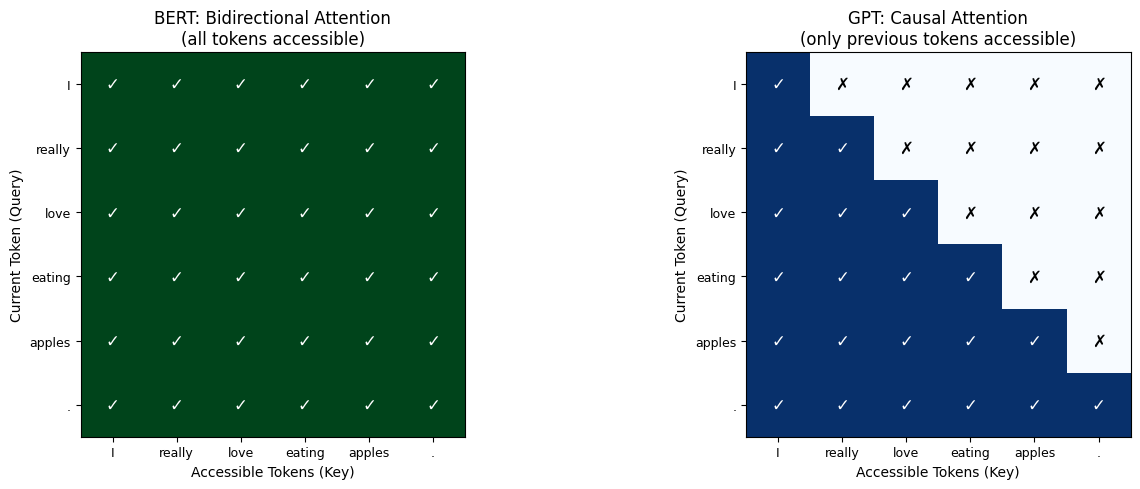

In [11]:
# Causal Attention 마스크 시각화
seq_len = 6
tokens = ['I', 'really', 'love', 'eating', 'apples', '.']

# Causal mask 생성 (하삼각 행렬)
causal_mask = torch.tril(torch.ones(seq_len, seq_len))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BERT 스타일: 양방향 (마스크 없음)
ax1 = axes[0]
bidirectional = torch.ones(seq_len, seq_len)
im1 = ax1.imshow(bidirectional.numpy(), cmap='Greens', vmin=0, vmax=1)
ax1.set_xticks(range(seq_len))
ax1.set_yticks(range(seq_len))
ax1.set_xticklabels(tokens, fontsize=9)
ax1.set_yticklabels(tokens, fontsize=9)
ax1.set_title('BERT: Bidirectional Attention\n(all tokens accessible)', fontsize=12)
ax1.set_xlabel('Accessible Tokens (Key)')
ax1.set_ylabel('Current Token (Query)')

# GPT 스타일: Causal (하삼각)
ax2 = axes[1]
im2 = ax2.imshow(causal_mask.numpy(), cmap='Blues', vmin=0, vmax=1)
ax2.set_xticks(range(seq_len))
ax2.set_yticks(range(seq_len))
ax2.set_xticklabels(tokens, fontsize=9)
ax2.set_yticklabels(tokens, fontsize=9)
ax2.set_title('GPT: Causal Attention\n(only previous tokens accessible)', fontsize=12)
ax2.set_xlabel('Accessible Tokens (Key)')
ax2.set_ylabel('Current Token (Query)')

for ax, data in [(ax1, bidirectional), (ax2, causal_mask)]:
    for i in range(seq_len):
        for j in range(seq_len):
            color = 'white' if data[i][j] == 1 else 'black'
            symbol = '✓' if data[i][j] == 1 else '✗'
            ax.text(j, i, symbol, ha='center', va='center', fontsize=12, color=color)

plt.tight_layout()
plt.show()

In [12]:
# Causal Attention 적용 예시
torch.manual_seed(42)

seq_len = 4
d_k = 8

Q = torch.randn(1, seq_len, d_k)
K = torch.randn(1, seq_len, d_k)
V = torch.randn(1, seq_len, d_k)

# Causal mask
causal_mask = torch.tril(torch.ones(seq_len, seq_len)).unsqueeze(0)  # (1, seq, seq)

print("=== GPT 스타일: Causal Attention ===")
output_causal, weights_causal = scaled_dot_product_attention(Q, K, V, mask=causal_mask)

print("\n=> 마스크 적용 후 각 토큰이 볼 수 있는 범위:")
print("   Token 0: Token 0만 참조")
print("   Token 1: Token 0, 1 참조")
print("   Token 2: Token 0, 1, 2 참조")
print("   Token 3: Token 0, 1, 2, 3 참조")

=== GPT 스타일: Causal Attention ===
내적 결과 (scores) shape: torch.Size([1, 4, 4])
스케일링 후 scores:
tensor([[-2.0544, -1.3068, -1.5423, -3.0557],
        [-1.2509,  1.5271, -0.4996,  0.4229],
        [-1.0697, -0.3879, -0.5083,  0.5155],
        [-0.5584, -0.6244, -0.5437,  0.2482]])
마스크 적용 후 scores:
tensor([[-2.0544,    -inf,    -inf,    -inf],
        [-1.2509,  1.5271,    -inf,    -inf],
        [-1.0697, -0.3879, -0.5083,    -inf],
        [-0.5584, -0.6244, -0.5437,  0.2482]])
Attention 가중치:
tensor([[1.0000, 0.0000, 0.0000, 0.0000],
        [0.0585, 0.9415, 0.0000, 0.0000],
        [0.2114, 0.4180, 0.3706, 0.0000],
        [0.1926, 0.1803, 0.1955, 0.4316]])

=> 마스크 적용 후 각 토큰이 볼 수 있는 범위:
   Token 0: Token 0만 참조
   Token 1: Token 0, 1 참조
   Token 2: Token 0, 1, 2 참조
   Token 3: Token 0, 1, 2, 3 참조


### GPT vs BERT 비교표

| 항목 | BERT | GPT |
|------|------|-----|
| **기반 구조** | Transformer Encoder | Transformer Decoder |
| **어텐션 방향** | 양방향 (Bidirectional) | 단방향 (Unidirectional, Left-to-Right) |
| **사전 학습 과제** | MLM + NSP | 다음 토큰 예측 (Autoregressive LM) |
| **마스크** | 없음 (모든 토큰 참조) | Causal mask (미래 토큰 차단) |
| **주요 용도** | 분류, NER, QA 등 이해(Understanding) 태스크 | 텍스트 생성(Generation) 태스크 |
| **입력 특수 토큰** | [CLS], [SEP], [MASK] | 없음 (또는 모델별 상이) |
| **대표 모델** | BERT-base (110M), BERT-large (340M) | GPT-2 (1.5B), GPT-3 (175B), GPT-4 |
| **Fine-tuning 방식** | Task-specific head 추가 | Prompt/In-context learning 또는 Fine-tuning |

---
## 6️⃣ 실습: HuggingFace로 BERT MLM & GPT Text Generation

### 실습 1: BERT Masked Language Model

In [13]:
from transformers import pipeline

# BERT MLM 파이프라인 생성
# 영어 BERT 사용 (한국어 BERT도 사용 가능: "klue/bert-base")
mlm_pipeline = pipeline('fill-mask', model='bert-base-uncased')

print("=== BERT Masked Language Model ===")
print("마스킹된 토큰을 양방향 문맥으로 예측합니다.\n")

# 예시 1
text1 = "The capital of France is [MASK]."
print(f"입력: {text1}")
results1 = mlm_pipeline(text1, top_k=5)
for r in results1:
    print(f"  예측: {r['token_str']:15s} (확률: {r['score']:.4f})")

print()

# 예시 2
text2 = "I want to [MASK] a book about machine learning."
print(f"입력: {text2}")
results2 = mlm_pipeline(text2, top_k=5)
for r in results2:
    print(f"  예측: {r['token_str']:15s} (확률: {r['score']:.4f})")

print()

# 예시 3: 양방향 문맥의 힘
text3 = "The [MASK] sat on the mat and purred softly."
print(f"입력: {text3}")
results3 = mlm_pipeline(text3, top_k=5)
for r in results3:
    print(f"  예측: {r['token_str']:15s} (확률: {r['score']:.4f})")

print("\n=> BERT는 [MASK] 위치의 좌우 문맥을 모두 활용하여 예측합니다.")
print("   'purred'라는 오른쪽 문맥 덕분에 'cat'을 높은 확률로 예측할 수 있습니다.")

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cuda:0


=== BERT Masked Language Model ===
마스킹된 토큰을 양방향 문맥으로 예측합니다.

입력: The capital of France is [MASK].
  예측: paris           (확률: 0.4168)
  예측: lille           (확률: 0.0714)
  예측: lyon            (확률: 0.0634)
  예측: marseille       (확률: 0.0444)
  예측: tours           (확률: 0.0303)

입력: I want to [MASK] a book about machine learning.
  예측: write           (확률: 0.9263)
  예측: read            (확률: 0.0442)
  예측: do              (확률: 0.0086)
  예측: publish         (확률: 0.0045)
  예측: make            (확률: 0.0019)

입력: The [MASK] sat on the mat and purred softly.
  예측: cat             (확률: 0.3399)
  예측: dog             (확률: 0.2228)
  예측: wolf            (확률: 0.0368)
  예측: kitten          (확률: 0.0360)
  예측: baby            (확률: 0.0281)

=> BERT는 [MASK] 위치의 좌우 문맥을 모두 활용하여 예측합니다.
   'purred'라는 오른쪽 문맥 덕분에 'cat'을 높은 확률로 예측할 수 있습니다.


### 실습 2: GPT Text Generation

In [14]:
# GPT-2 텍스트 생성 파이프라인
generator = pipeline('text-generation', model='gpt2')

print("=== GPT-2 Text Generation ===")
print("이전 토큰들을 기반으로 다음 토큰을 자동회귀적으로 생성합니다.\n")

# 예시 1: 간단한 텍스트 생성
prompt1 = "Artificial intelligence is"
print(f"프롬프트: \"{prompt1}\"")
result1 = generator(prompt1, max_length=50, num_return_sequences=1, 
                    do_sample=True, temperature=0.7, truncation=True)
print(f"생성 결과: {result1[0]['generated_text']}")

print("\n" + "-"*60 + "\n")

# 예시 2: 다른 프롬프트
prompt2 = "The transformer architecture revolutionized"
print(f"프롬프트: \"{prompt2}\"")
result2 = generator(prompt2, max_length=60, num_return_sequences=1,
                    do_sample=True, temperature=0.7, truncation=True)
print(f"생성 결과: {result2[0]['generated_text']}")

Device set to use cuda:0
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== GPT-2 Text Generation ===
이전 토큰들을 기반으로 다음 토큰을 자동회귀적으로 생성합니다.

프롬프트: "Artificial intelligence is"


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=60) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


생성 결과: Artificial intelligence is designed to be able to do what it does best and do it better than anyone else. It's not like it's all going to be perfect.

In any case, we've already seen that computers have a high level of capability and can do some pretty amazing things. If you're thinking of something like video games, for example, or the real world, the ability to do something that's so important, that's where the next frontier comes.

So, I'm sure that we will see some sort of technology that can help us move away from the world in which we live, but I think we'll see some technology that will help us move away from what's so important for us.

Q: So, the next great thing that's going to happen, I think, is that we'll see a technology that will allow us to do things like digital cameras, and the ability to do some really incredible things for things like health monitoring, and so on.

And, I think we're going to see a technology that allows us to do things like smart glasses, an

In [15]:
# Temperature에 따른 생성 결과 비교
print("=== Temperature 비교 ===")
print("Temperature가 낮을수록 확정적, 높을수록 다양한 텍스트 생성\n")

prompt = "Deep learning is a subset of"

for temp in [0.3, 0.7, 1.0, 1.5]:
    result = generator(prompt, max_length=40, num_return_sequences=1,
                       do_sample=True, temperature=temp, truncation=True)
    generated = result[0]['generated_text']
    print(f"Temperature={temp}: {generated}")
    print()

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=40) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== Temperature 비교 ===
Temperature가 낮을수록 확정적, 높을수록 다양한 텍스트 생성



Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=40) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Temperature=0.3: Deep learning is a subset of the human brain that is responsible for the processing of information.

In this paper, we present a novel approach to the understanding of neural plasticity and how it may be applied to the treatment of cognitive impairment. We propose that the use of neural plasticity to treat cognitive impairment may be useful in the treatment of cognitive impairment. We also propose that the use of neural plasticity to treat cognitive impairment may be useful in the treatment of other cognitive disorders.



Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=40) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Temperature=0.7: Deep learning is a subset of the more general human brain, which consists of parts of the brain that have been processed by neurons to learn new information.

Scientists have previously used it to identify a wide range of diseases, including Alzheimer's, Parkinson's, Huntington's and ALS.

"It is an amazing discovery, but what we're dealing with now is a relatively new, small, and yet very powerful way of learning," said Dr. Michael T. Taff, a neuroscientist at the University of South Carolina at Charlotte.

Using the technique, which is being developed by scientists at the University of Toronto, researchers have shown that the idea of learning that is the hallmark of autism is one that can be used to treat other cognitive problems.

The researchers discovered that autism can be triggered by a part of the brain in which it is necessary to process information: the amygdala, which is activated during emotional processing.

"We're going to be able to detect signals from t

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=40) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Temperature=1.0: Deep learning is a subset of the "super intelligence" that could enable us to gain more control over our own neural networks. Some of these super-intelligence will be able to be used in the future to enable future AI as well.

With any luck, this will happen very soon for all our AI, as this article outlines. But there's a problem. It's not hard to imagine that we will learn new things when AI improves enough to become powerful enough to drive us into certain future situations. Now's the time: is it too late to just say:

It doesn't matter. We must do what is in our best interest

... so we're not distracted with the future; it's time to make the best of it

— David P. Hall

The above is a fairly simple piece of advice, if you ask me! You can make an excellent case and argue that with such a good mind — that is, as opposed to just being distracted with the future — such as an employee, business partner or parent — that you can help your AI evolve to use the tools that 

입력: "The cat sat on the"

다음 토큰 예측 Top-10:
----------------------------------------
  ' floor         ' : 0.0764 (7.6%)
  ' bed           ' : 0.0653 (6.5%)
  ' couch         ' : 0.0541 (5.4%)
  ' ground        ' : 0.0521 (5.2%)
  ' edge          ' : 0.0478 (4.8%)
  ' bench         ' : 0.0316 (3.2%)
  ' table         ' : 0.0315 (3.2%)
  ' sofa          ' : 0.0288 (2.9%)
  ' other         ' : 0.0199 (2.0%)
  ' back          ' : 0.0190 (1.9%)


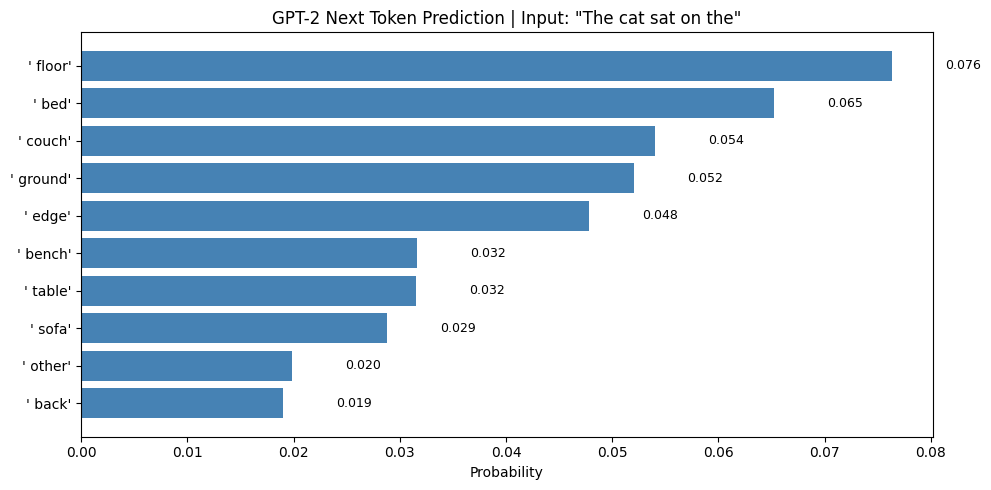

In [16]:
# GPT-2 토큰 확률 분석
from transformers import GPT2LMHeadModel, GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
model = GPT2LMHeadModel.from_pretrained('gpt2')
model.eval()

text = "The cat sat on the"
inputs = tokenizer(text, return_tensors='pt')

with torch.no_grad():
    outputs = model(**inputs)
    # 마지막 토큰 위치의 logit에서 다음 토큰 예측
    next_token_logits = outputs.logits[0, -1, :]
    probs = F.softmax(next_token_logits, dim=-1)

# 상위 10개 후보 토큰
top_k = 10
top_probs, top_indices = torch.topk(probs, top_k)

print(f"입력: \"{text}\"")
print(f"\n다음 토큰 예측 Top-{top_k}:")
print("-" * 40)

tokens_list = []
probs_list = []
for prob, idx in zip(top_probs, top_indices):
    token = tokenizer.decode(idx)
    tokens_list.append(token)
    probs_list.append(prob.item())
    print(f"  '{token:15s}' : {prob.item():.4f} ({prob.item()*100:.1f}%)")

# 시각화
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(range(top_k), probs_list[::-1], color='steelblue')
ax.set_yticks(range(top_k))
ax.set_yticklabels([f"'{t}'" for t in tokens_list[::-1]])
ax.set_xlabel('Probability')
ax.set_title(f'GPT-2 Next Token Prediction | Input: "{text}"')

for bar, prob in zip(bars, probs_list[::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{prob:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

---
## 정리

### 오늘 배운 내용

1. **Transformer 아키텍처**: Encoder-Decoder 구조, Self-Attention의 수학적 원리 (Q, K, V)
2. **Self-Attention 구현**: Scaled Dot-Product Attention과 Multi-Head Attention을 PyTorch로 직접 구현
3. **Positional Encoding**: Sinusoidal 방식으로 위치 정보를 인코딩하는 원리와 시각화
4. **BERT**: 양방향 Encoder 기반, MLM + NSP로 사전 학습, 이해(Understanding) 태스크에 강점
5. **GPT**: 단방향 Decoder 기반, Autoregressive 방식, 생성(Generation) 태스크에 강점
6. **실습**: HuggingFace pipeline을 활용한 BERT MLM과 GPT 텍스트 생성

### 핵심 비교
- **BERT** = Encoder + 양방향 → "문맥 이해"에 특화
- **GPT** = Decoder + 단방향 → "텍스트 생성"에 특화
- 최근 트렌드: GPT 계열 (Decoder-only) 모델이 스케일링과 함께 이해+생성 모두 가능한 방향으로 발전

In [ ]:
print("Session 3 완료!")
print("다음 세션(Session 4): 생성 AI와 LLM 개요")

Session 3 완료!
다음 세션(Session 4): 생성 AI와 LLM 개요


: 